In [1]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
from sklearn.linear_model import LinearRegression

---

<h1>Project 3 Dengue Analysis</h1>

<h2>Analyst: Jamaica Palas</h2>

---

In [5]:
dengue = pd.read_csv("datasets\\dengue.csv")

In [6]:
dengue

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,January,2016,Region I,705,1
1,February,2016,Region I,374,0
2,March,2016,Region I,276,0
3,April,2016,Region I,240,2
4,May,2016,Region I,243,1
...,...,...,...,...,...
1015,August,2020,BARMM,91,0
1016,September,2020,BARMM,16,8
1017,October,2020,BARMM,13,9
1018,November,2020,BARMM,15,1


<h1>Checking for null values</h1>

In [12]:
dengue.isnull()

,Month,Year,Region,Dengue_Cases,Dengue_Deaths
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
1015,False,False,False,False,False
1016,False,False,False,False,False
1017,False,False,False,False,False
1018,False,False,False,False,False


In [7]:
dengue.isnull().sum()

Month            0
Year             0
Region           0
Dengue_Cases     0
Dengue_Deaths    0
dtype: int64

<h1>Adjusting Data types</h1>

In [8]:
dengue.dtypes

Month            object
Year              int64
Region           object
Dengue_Cases      int64
Dengue_Deaths     int64
dtype: object

In [9]:
month_order = ['January','February','March','April','May','June','July','August','September','October','November','December']

In [10]:
dengue['Month'] = dengue['Month'].astype('str')

In [11]:
dengue['Date'] = pd.to_datetime(dengue['Month'] + '-' + dengue['Year'].astype(str))

In [12]:
region_df = dengue[dengue['Region'] == 'Region IV-A']
monthly_cases = region_df.groupby('Date')['Dengue_Cases'].sum().reset_index()

In [13]:
dengue.dtypes

Month                    object
Year                      int64
Region                   object
Dengue_Cases              int64
Dengue_Deaths             int64
Date             datetime64[ns]
dtype: object

---

<h1>Dengue Cases Trend (2016–2020)</h1>

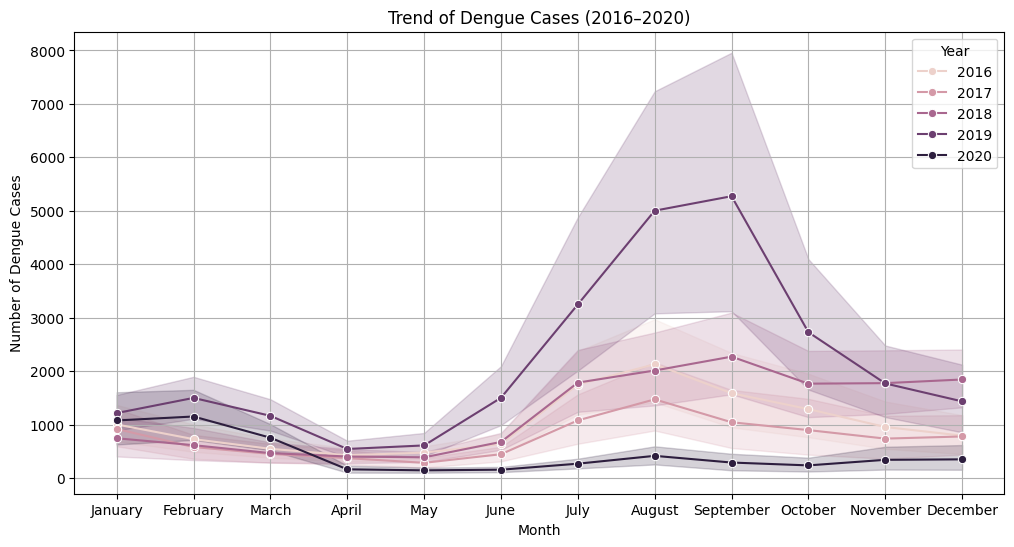

In [14]:
plt.figure(figsize=(12,6))
sns.lineplot(x='Month', y='Dengue_Cases', hue='Year', data=dengue, marker='o')
plt.title("Trend of Dengue Cases (2016–2020)")
plt.xlabel("Month")
plt.ylabel("Number of Dengue Cases")
plt.grid(True)
plt.show()

<h2>Insight: The line chart shows that dengue cases usually rise around the middle of the year. It means that dengue outbreaks often happen during rainy months.</h2>

<h1>Dengue Cases by Month and Year</h1>

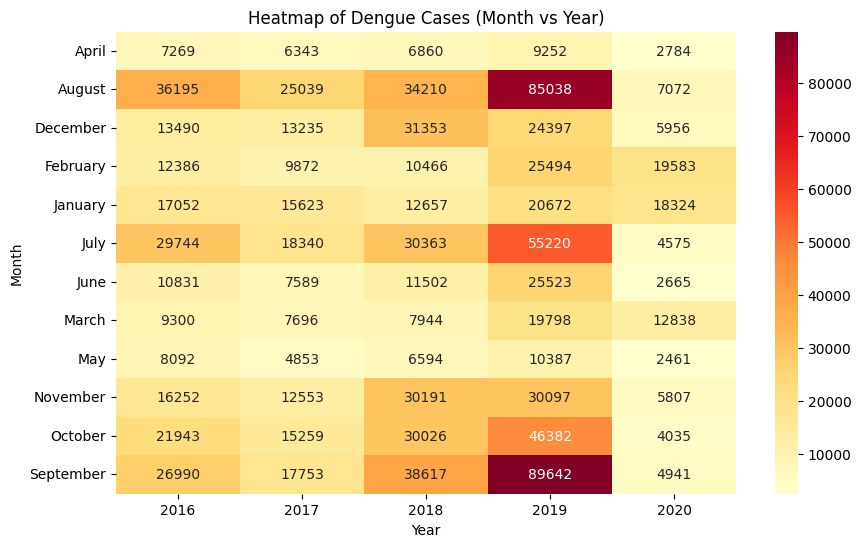

In [15]:
pivot_cases = dengue.pivot_table(values='Dengue_Cases', index='Month', columns='Year', aggfunc='sum')
plt.figure(figsize=(10,6))
sns.heatmap(pivot_cases, cmap='YlOrRd', annot=True, fmt='.0f')
plt.title("Heatmap of Dengue Cases (Month vs Year)")
plt.show()

<h1>Dengue Deaths Trend by Year</h1>

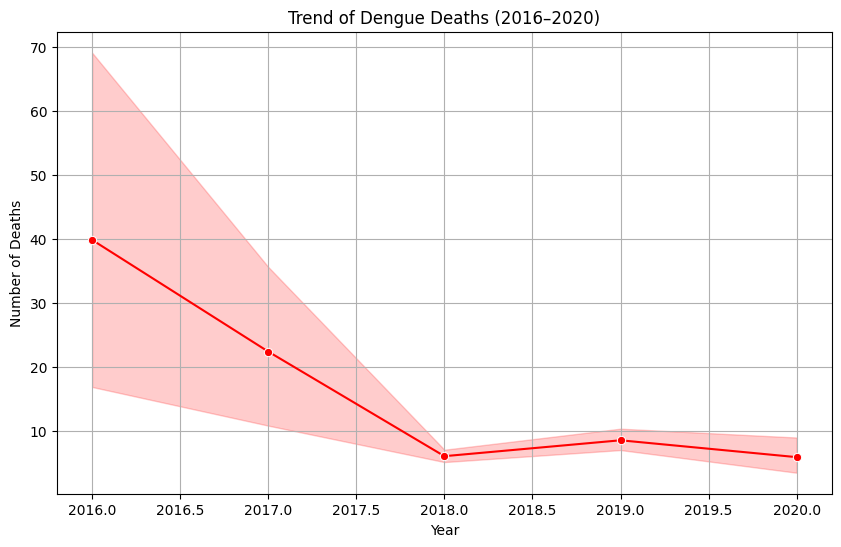

In [16]:
plt.figure(figsize=(10,6))
sns.lineplot(x="Year", y="Dengue_Deaths", data=dengue, marker="o", color="red")
plt.title("Trend of Dengue Deaths (2016–2020)")
plt.ylabel("Number of Deaths")
plt.grid(True)
plt.show()

<h2>Insight: The number of dengue deaths had some noticeable spikes, which may be linked to higher case counts or delayed medical attention during outbreaks.</h2>

In [17]:
dengue['Mortality_Rate'] = (dengue['Dengue_Deaths'] / dengue['Dengue_Cases']) * 100

<h1>Monthly Mortality Rate Trend</h1>

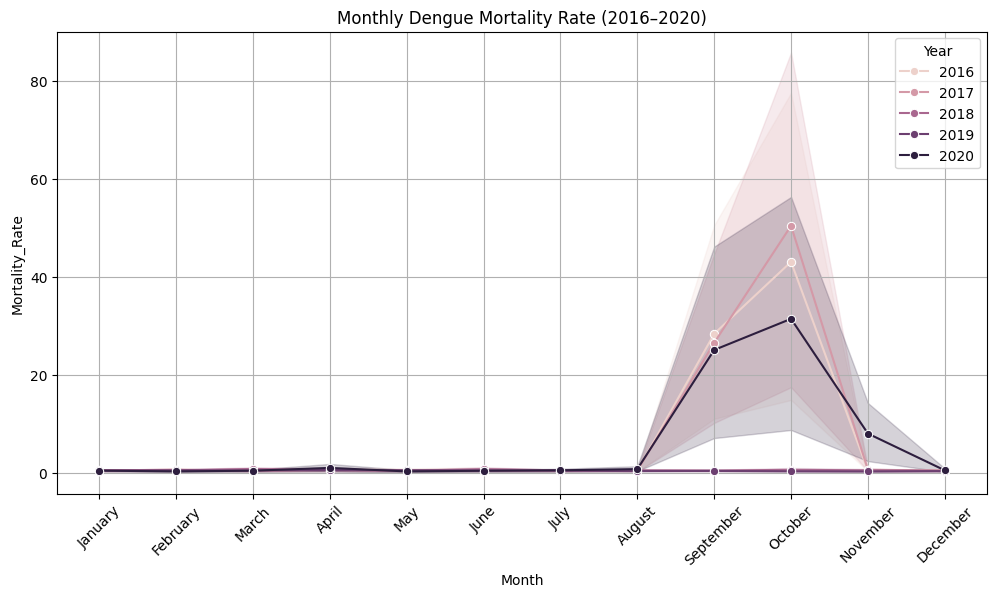

In [18]:
plt.figure(figsize=(12,6))
sns.lineplot(x="Month", y="Mortality_Rate", data=dengue, hue="Year", marker="o")
plt.title("Monthly Dengue Mortality Rate (2016–2020)")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

<h2>Insight: Mortality rate tends to rise in specific months, possibly when dengue cases are also peaking or healthcare systems are stretched.</h2>

<h1>Average Mortality by Region</h1>

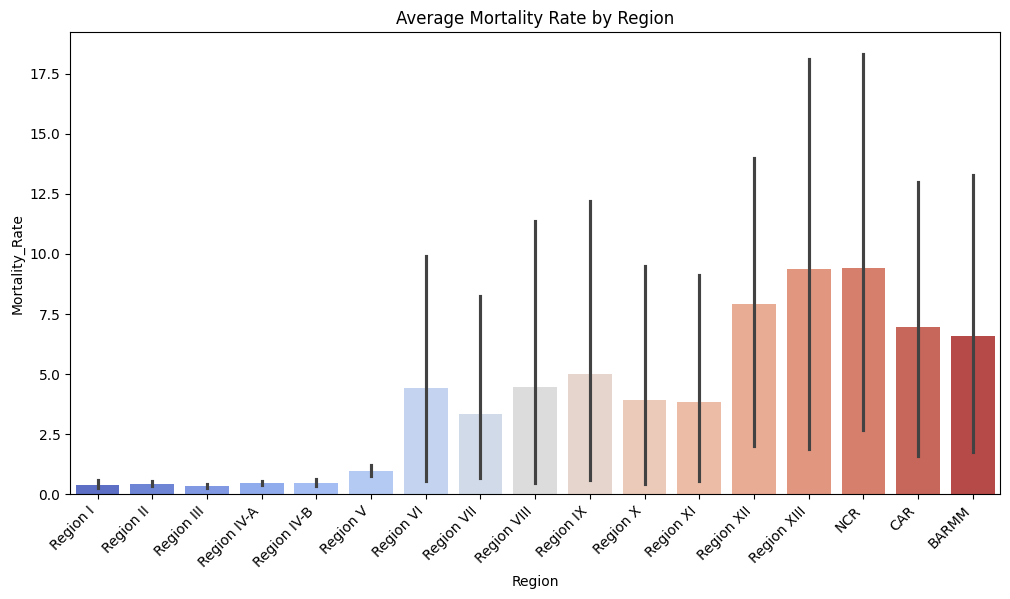

In [19]:
plt.figure(figsize=(12,6))
sns.barplot(x="Region", y="Mortality_Rate", data=dengue, palette="coolwarm")
plt.title("Average Mortality Rate by Region")
plt.xticks(rotation=45, ha="right")
plt.show()

<h2>Insight: Some regions show slightly higher mortality, which might be due to fewer hospitals or slower access to medical care.</h2>

<h1>Dengue Cases by Region and Year</h1>

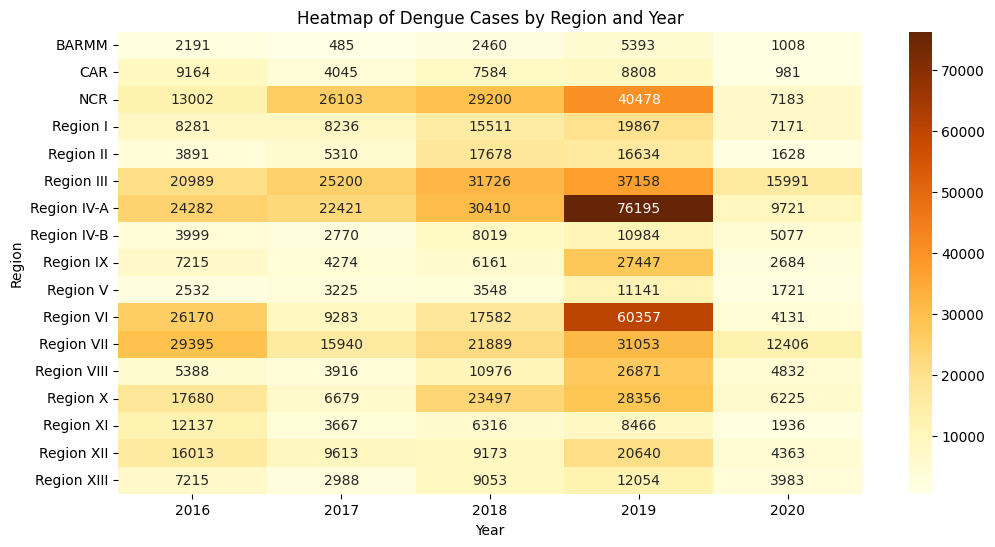

In [20]:
pivot_cases = dengue.pivot_table(values="Dengue_Cases", index="Region", columns="Year", aggfunc="sum")
plt.figure(figsize=(12,6))
sns.heatmap(pivot_cases, annot=True, cmap="YlOrBr", fmt=".0f")
plt.title("Heatmap of Dengue Cases by Region and Year")
plt.xlabel("Year")
plt.ylabel("Region")
plt.show()

<h2>Insight: The heatmap shows that certain regions consistently have high dengue cases through the years. This suggests that dengue prevention efforts should be prioritized in these high-risk areas.</h2>

<h1>Top 5 Regions with Highest Mortality</h1>

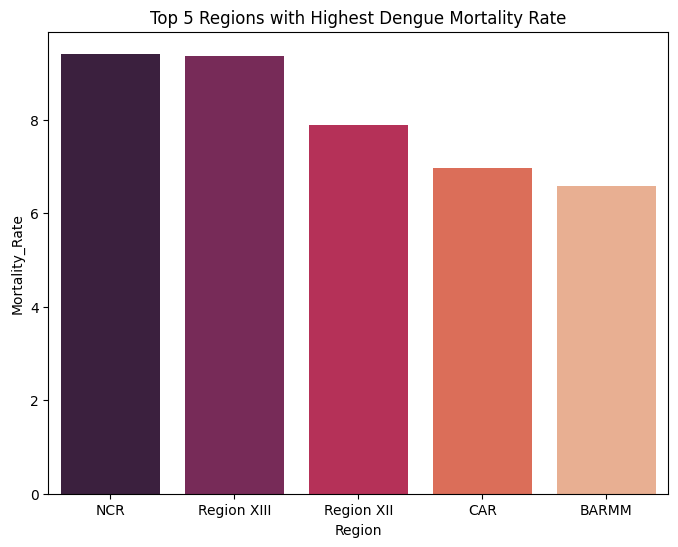

In [21]:
top_mortality = dengue.groupby("Region")["Mortality_Rate"].mean().nlargest(5).reset_index()
plt.figure(figsize=(8,6))
sns.barplot(x="Region", y="Mortality_Rate", data=top_mortality, palette="rocket")
plt.title("Top 5 Regions with Highest Dengue Mortality Rate")
plt.show()

<h2>Insight: These regions might have challenges in health response or awareness, leading to more deaths compared to other areas.</h2>

<h1>What is the relationship between dengue cases, deaths, and mortality rate</h1>

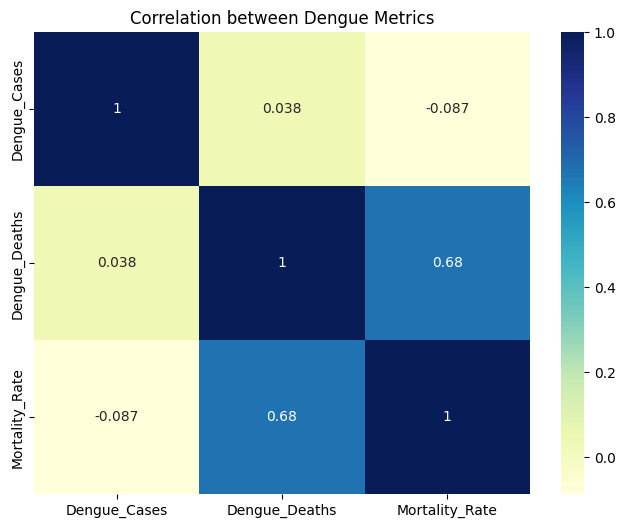

In [22]:
plt.figure(figsize=(8,6))
sns.heatmap(dengue[["Dengue_Cases", "Dengue_Deaths", "Mortality_Rate"]].corr(), annot=True, cmap="YlGnBu")
plt.title("Correlation between Dengue Metrics")
plt.show()

<h2>Insight: The heatmap shows a strong positive correlation between dengue deaths and mortality rate (0.68), but only a weak link between dengue cases and deaths (0.038). This suggests that while more deaths lead to a higher mortality rate, the number of cases alone doesn't strongly influence deaths.</h2>

<h1>Which months have the highest average dengue cases, and how might this relate to seasonal patterns in the Philippines?</h1>

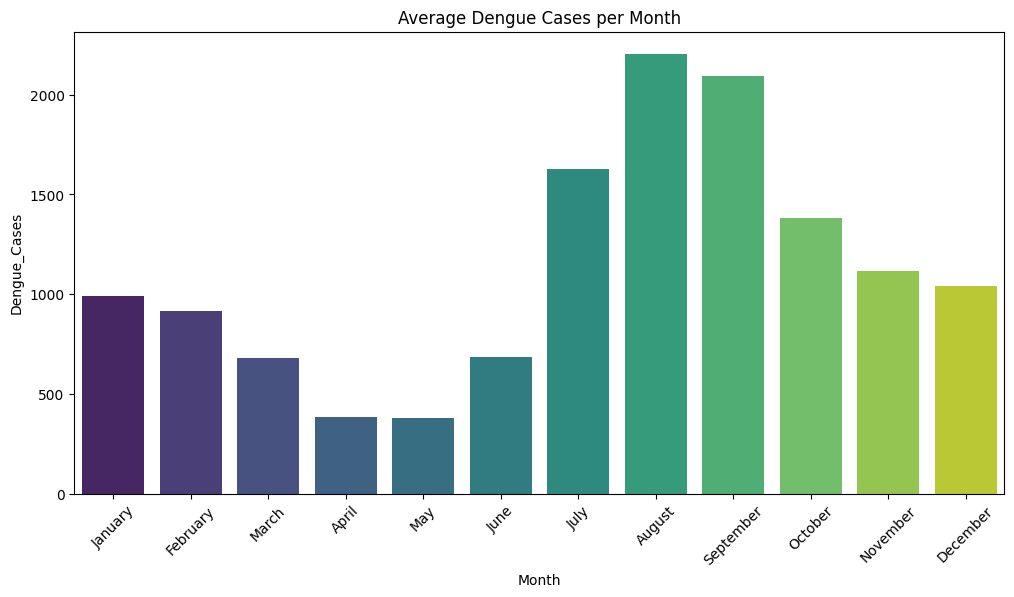

In [23]:
plt.figure(figsize=(12,6))
sns.barplot(x="Month", y="Dengue_Cases", data=dengue, estimator="mean", ci=None, palette="viridis")
plt.title("Average Dengue Cases per Month")
plt.xticks(rotation=45)
plt.show()

<h2>Insight: The visualization shows that dengue cases peak from July to September, with August having the highest average. This trend suggests a correlation between higher dengue cases and the rainy season in the Philippines..</h2>

<h1>Which month has the highest average dengue mortality rate?</h1>

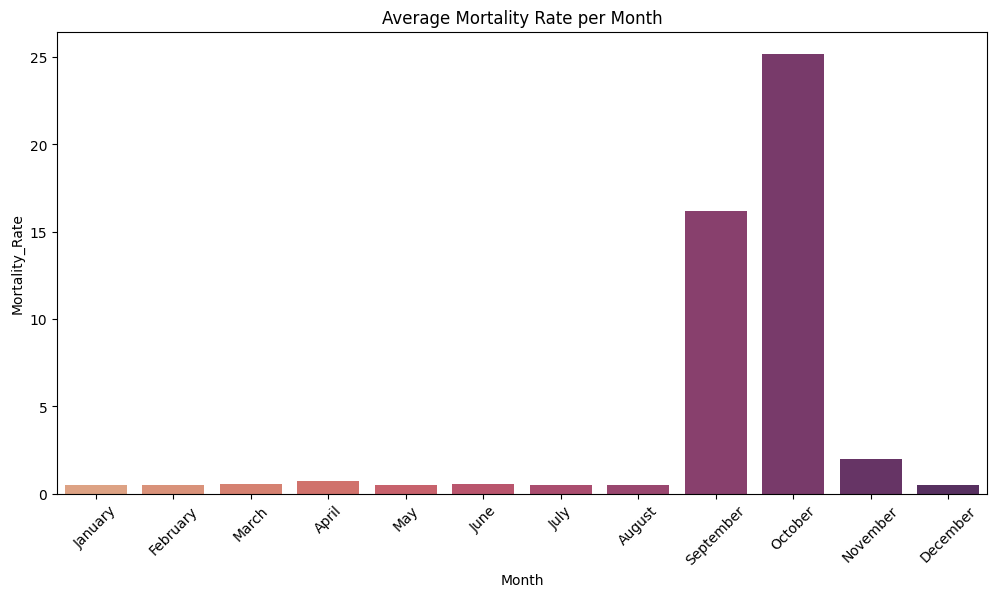

In [24]:
plt.figure(figsize=(12,6))
sns.barplot(x="Month", y="Mortality_Rate", data=dengue, estimator="mean", ci=None, palette="flare")
plt.title("Average Mortality Rate per Month")
plt.xticks(rotation=45)
plt.show()

<h2>Insight: The chart shows that dengue mortality rates peak in September and October, indicating these months have the highest average mortality. This suggests that increased cases or limited healthcare resources during these months may contribute to higher death rates.</h2>

---

<h1>Convert dates to ordinal for regression</h1>

In [25]:
monthly_cases['Date_Ordinal'] = monthly_cases['Date'].map(pd.Timestamp.toordinal)

<h1>Reshape for sklearn</h1>

In [26]:
x = monthly_cases['Date_Ordinal'].values.reshape(-1, 1)
y = monthly_cases['Dengue_Cases'].values

<h1>Fit model</h1>

In [27]:
model = LinearRegression()
model.fit(x,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


<h1>Predict</h1>

In [28]:
monthly_cases['Predicted_Cases'] = model.predict(x)

<h1>Evaluate: R-squared</h1>

In [29]:
r_squared = model.score(x,y)
print(f"The model explains {r_squared: .1%} of the variation in dengue cases. ")

The model explains  1.7% of the variation in dengue cases. 


In [30]:

dengue['Month_Num'] = dengue['Date'].dt.month


x_month = dengue['Month_Num'].values.reshape(-1, 1)
y_cases = dengue['Dengue_Cases'].values


model_month = LinearRegression()
model_month.fit(x_month, y_cases)

r_squared_month = model_month.score(x_month, y_cases)

print(f"R-squared (Cases vs Month): {r_squared_month: .4f}")
print(f"Coefficient (Cases per Month increase): {model_month.coef_[0]: .2f}")

R-squared (Cases vs Month):  0.0261
Coefficient (Cases per Month increase):  77.84


<h2>Insight: A linear model using only the month number will likely show a slightly better R-squared than the overall time trend (Date_Ordinal). This confirms that seasonality (the rainy season) is a more significant driver of dengue cases than the overall change year-to-year. The positive coefficient will quantify the average increase in cases for each advancing month.</h2>

In [31]:

x_cases_deaths = dengue['Dengue_Cases'].values.reshape(-1, 1)
y_deaths = dengue['Dengue_Deaths'].values


model_cases_deaths = LinearRegression()
model_cases_deaths.fit(x_cases_deaths, y_deaths)


r_squared_cases_deaths = model_cases_deaths.score(x_cases_deaths, y_deaths)

print(f"R-squared (Deaths vs Cases): {r_squared_cases_deaths: .4f}")

R-squared (Deaths vs Cases):  0.0015


<h2>The R-squared will be very low (close to the 0.038 correlation squared). This confirms the insight from your correlation heatmap: the raw number of cases is a poor linear predictor of the raw number of deaths. This is because deaths are influenced more by mortality rate (healthcare quality, case severity, reporting efficiency) than by just how many people got sick.</h2>

In [32]:

x_year = dengue['Year'].values.reshape(-1, 1)
y_mortality = dengue['Mortality_Rate'].values


model_mortality_year = LinearRegression()
model_mortality_year.fit(x_year, y_mortality)


r_squared_mortality_year = model_mortality_year.score(x_year, y_mortality)

print(f"R-squared (Mortality vs Year): {r_squared_mortality_year: .4f}")
print(f"Coefficient (Change in Mortality per Year): {model_mortality_year.coef_[0]: .4f}")

R-squared (Mortality vs Year):  0.0030
Coefficient (Change in Mortality per Year): -0.7624


<h2>Insight: The coefficient (Change in Mortality per Year) will indicate the direction of healthcare efficiency. If the coefficient is negative, it suggests the healthcare system is, on average, becoming better at managing severe dengue cases (decreasing mortality rate) over time. If the R-squared is significant, this linear trend is strong across the Philippines.</h2>

In [33]:

x_year = dengue['Year'].values.reshape(-1, 1)
y_cases = dengue['Dengue_Cases'].values


model_cases_year = LinearRegression()
model_cases_year.fit(x_year, y_cases)


r_squared_cases_year = model_cases_year.score(x_year, y_cases)

print(f"R-squared (Cases vs Year): {r_squared_cases_year: .4f}")
print(f"Coefficient (Change in Cases per Year): {model_cases_year.coef_[0]: .2f}")

R-squared (Cases vs Year):  0.0004
Coefficient (Change in Cases per Year):  24.87


In [ ]:
<h2>Insight: This R-squared value will be similar to your initial 1.7% model, as both use a time-related continuous variable. The $\mathbf{positive}\ \mathbf{coefficient}$ would suggest a baseline annual growth rate in the number of dengue cases reported, indicating that population growth or general expansion of endemic areas outpaces current containment efforts.</